# 3. Visualizing Facial Expressions
*written by Eshin Jolly*

In this tutorial we'll explore plotting in Py-Feat using functions from the `feat.plotting` module along with plotting methods using the Fex data class. You can try it out interactively in Google Collab: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cosanlab/py-feat/blob/main/docs/basic_tutorials/03_plotting.ipynb)


To help visualize facial expressions in a standardized way, Py-Feat includes a pre-trained partial-least-squares (PLS) model that can map between an array of AU intensities (between 0-N) and facial landmark coordinates. Just pass in a numpy array of AU intensities to the `plot_face()` function to visualize the resulting facial expression. In general we find that a 4 by 5 aspect ratio seems to work best when plotting faces (default in `plot_face()`).

For more details on how this visualization model was trained and how to train your own see [this advanced tutorial](https://py-feat.org/extra_tutorials/trainAUvisModel.html). 


In [ ]:
# Uncomment the line below and run this only if you're using Google Collab
# !pip install -q py-feat

## 3.1 Plotting a neutral (default) face

To plot a neutral facial expression just pass in an array of 0s to `plot_face()` which always returns a matplotlib axis handle:

/Users/lukechang/Github/py-feat/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


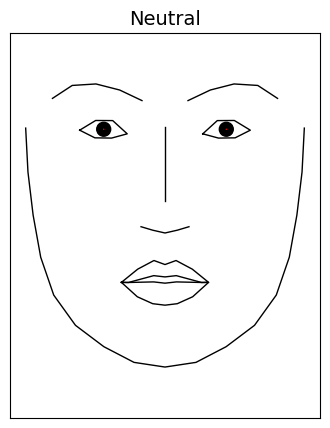

In [1]:
from feat.plotting import plot_face
import numpy as np

# 20 dimensional vector of AU intensities
# AUs ordered as:
# 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 14, 15, 17, 20, 23, 24, 25, 26, 28, 43
neutral = np.zeros(20)

ax = plot_face(au=neutral, title='Neutral')

## 3.2 Plotting AU activations

Plotting facial expressions from AU activity is just as a simple. Below we increase the intensity of AU1 (inner brow raiser) to 1 before passing it to `plot_face()`. 

The default visualization model in py-feat 0.7+ (`PLSAULandmarkModel`, trained on ~350K CelebV-HQ frames) expects AU intensities on the **[0, 1] scale that the `xgb` AU detector outputs** — `0` = AU off, `1` = fully activated. Values larger than 1 push the model past its training distribution and produce cartoonish/exaggerated expressions. (The legacy v1 model used a [0, 5] FACS-style scale; if you load it explicitly with `load_viz_model('pyfeat_aus_to_landmarks')`, the old `AU=3` convention still applies there.)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


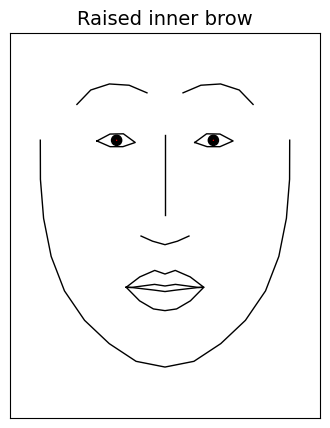

In [2]:
raised_inner_brow = np.zeros(20)
# Increase AU1 intensity: Inner brow raiser (1.0 = fully activated on xgb's scale)
raised_inner_brow[0] = 1

_ = plot_face(au=raised_inner_brow, title="Raised inner brow")

### Adding muscle heatmaps to the plot

We can also visualize how AU intensity affects the underlying facial muscle movement by passing in a dictionary of facial muscle names and colors (or the value `'heatmap'`) to `plot_face()`. 

Below we activate 2 AUs and use the key `'all'` with the value `'heatmap'` to overlay muscle movement intensities affected by these specific AUs:

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


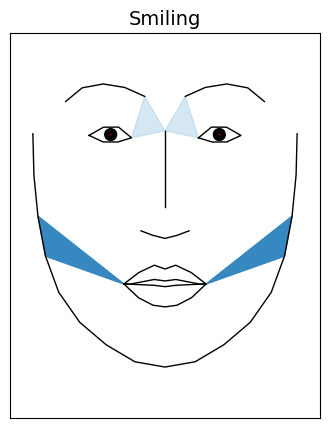

In [3]:
# Activate AUs (xgb [0, 1] scale: AU01 partially active, AU11 fully active)
smiling = np.array([.5, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Overlay muscles 
muscles = {'all': 'heatmap'}

_ = plot_face(au = smiling, muscles = muscles, title='Smiling')

But it's also possible to arbitrarily highlight any facial muscle by setting it to a color instead. This ignores the AU intensity and useful for highlighting specific facial muscles. Below we highlight two different muscles on a neutral face:

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


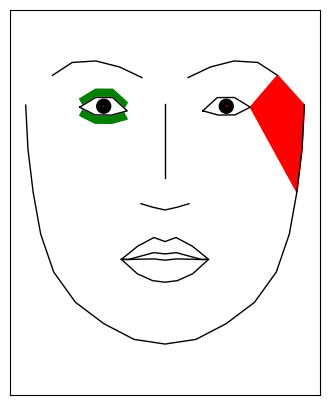

In [4]:
muscles = {'temporalis_r_rel': "red", 'pars_palp_l': 'green'}
_ = plot_face(au=neutral, muscles=muscles)

### Adding gaze vectors to the plot

Py-Feat also supports overlaying gaze vectors to indicate where the eyes are looking. By default the eyes are always in a neutral position pointing forward. But it's possible to pass an array to the `gaze` argument of `plot_face()` to move the eyes.  
Gaze vectors are length 4 `(lefteye_x, lefteye_y, righteye_x, righteye_y)` where the y orientation is positive for looking upwards.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


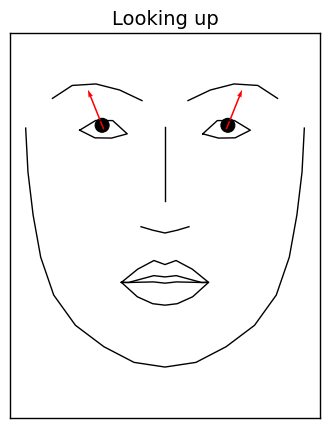

In [8]:
# Add some gaze vectors: (lefteye_x, lefteye_y, righteye_x, righteye_y)
gaze = [-1, 5, 1, 5]

_ = plot_face(au=neutral, gaze=gaze, title='Looking up')

### Plotting gaze from real images (L2CS model)

The synthetic-face example above takes a manually-specified gaze 4-vector.
For real images, py-feat 0.7+ includes the **L2CS** gaze model
(Abdelrahman et al. 2022, ResNet50) — the default `gaze_model` for both
`Detector` and `MPDetector`. After running detection, the resulting `Fex`
DataFrame has `gaze_pitch` and `gaze_yaw` columns (radians), and
`Fex.plot_detections(gazes=True)` automatically draws a gaze arrow from each
face's bbox center in the predicted direction.

/var/folders/t6/l70_tp4s3xx96772lc2504640000gn/T/ipykernel_34988/4027613082.py:4: UserWarning: face_model='retinaface' does not regress 6DoF head pose. Pose columns are populated via the landmarks-to-pose MLP (distilled from img2pose on CelebV-HQ, ~5° avg MAE vs img2pose). PnP-DLT is used as a fallback when the MLP weights aren't available. Use face_model='img2pose' for the slowest, highest-accuracy path. See feat.utils.face_pose_mlp for details.
  gaze_detector = Detector(au_model="xgb", emotion_model=None, identity_model=None)
100%|██████████| 1/1 [00:00<00:00,  2.42it/s]


gaze columns: ['gaze_pitch', 'gaze_yaw', 'gaze_angle']
   gaze_pitch  gaze_yaw
0   -0.114645 -0.372506
1   -0.211284 -0.346252
2   -0.488092  0.662024
3   -0.599363  0.503887
4   -0.054296 -0.051697


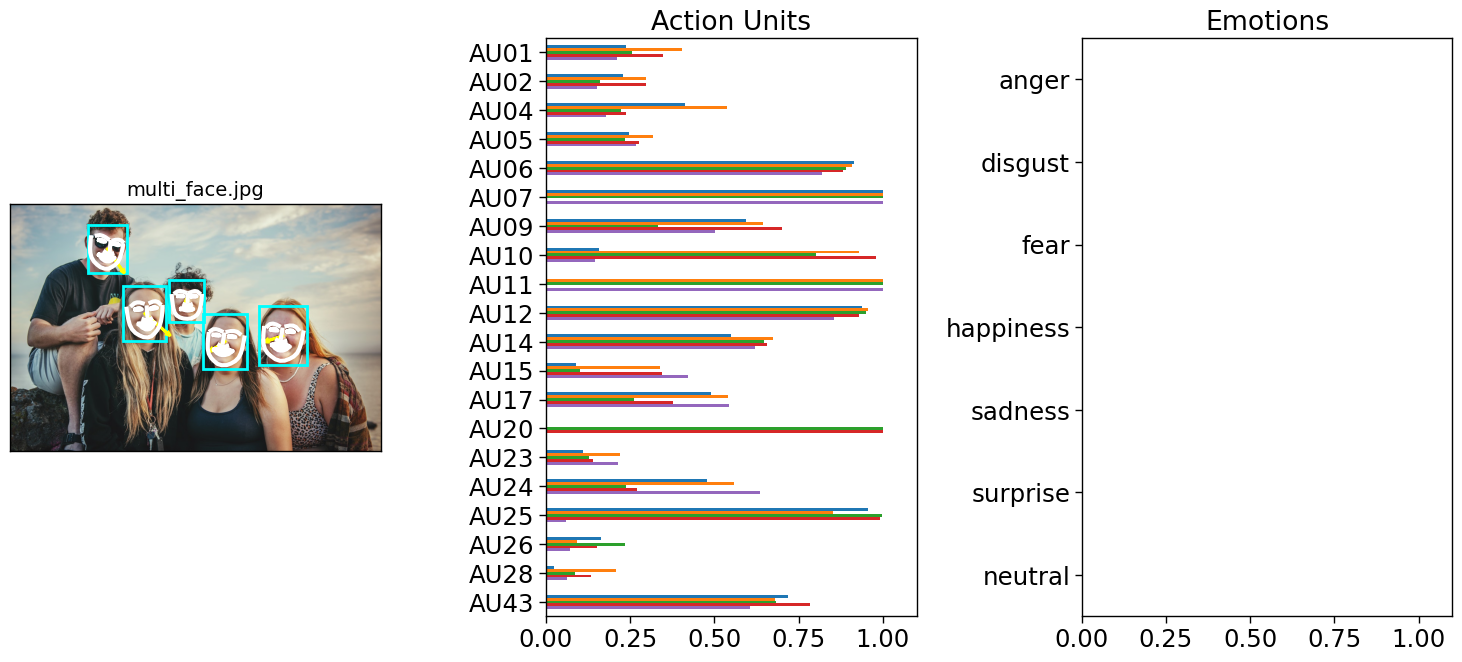

In [9]:
from feat.detector import Detector

# Run the Detector on a real image. gaze_model='l2cs' is the default in v0.7.
gaze_detector = Detector(au_model="xgb", emotion_model=None, identity_model=None)
fex_real = gaze_detector.detect(["../../feat/tests/data/multi_face.jpg"])

# fex_real has gaze_pitch / gaze_yaw columns (radians) for each detected face.
print("gaze columns:", fex_real.gaze_columns)
print(fex_real[["gaze_pitch", "gaze_yaw"]])

# plot_detections renders a yellow gaze arrow from each face's bbox center
# in the predicted direction, overlaid on the detected landmarks.
_ = fex_real.plot_detections(faces="landmarks", gazes=True, muscles=False)

### Adding vectorfield arrows to highlight facial movement

One way we can highlight how a faces change between two expressions is by overlaying a vectorfield of arrows for each facial landmark pointing in the direction of movement from one face to another. To do so, we use the `predict()` function to get landmark data for each array of AU intensities we want to plot and generate a `vectors` dictionary with keys for the `'target'` and `'reference'` faces. Then we can pass this dictionary to the `vectorfield` argument of `plot_face()`:

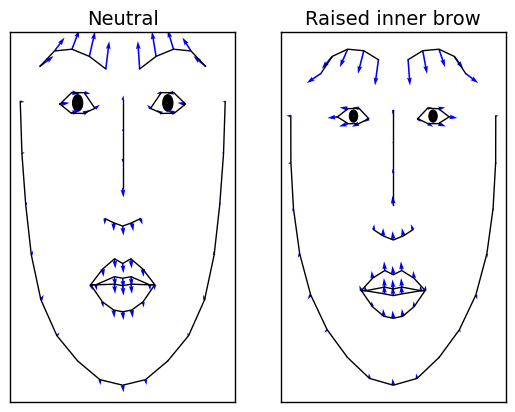

In [10]:
from feat.plotting import predict
import matplotlib.pyplot as plt

# Get landmarks
neutral_landmarks = predict(neutral)
raised_inner_brow_landmarks = predict(raised_inner_brow)

# Vectorfield drawn on the *reference* face, pointing toward the *target* face.
# Left panel: arrows start at neutral landmarks and tip at the raised-brow positions.
neutral_to_target = {
    "target": raised_inner_brow_landmarks,
    "reference": neutral_landmarks,
    "color": "blue",
}
# Right panel: arrows start at raised-brow landmarks and tip back at the neutral
# positions — i.e., the reverse of the left panel.
target_to_neutral = {
    "target": neutral_landmarks,
    "reference": raised_inner_brow_landmarks,
    "color": "blue",
}

fig, axes = plt.subplots(1, 2)
# Vectorfield goes from neutral -> target on neutral face
_ = plot_face(ax=axes[0], au=neutral, title="Neutral", vectorfield=neutral_to_target)
# Vectorfield goes target -> neutral on target face
_ = plot_face(
    ax=axes[1],
    au=raised_inner_brow,
    title="Raised inner brow",
    vectorfield=target_to_neutral,
)


## 3.3 Animating facial expressions

Py-Feat includes an `animate_face()` function which makes it easy to "morph" one facial expression into another by interpolating between AU intensities. This function generates a GIF specified by the `save` argument. You can use this function in two ways:
1. Using the `AU` keyword argument and a single scalar value for `start` and `end`
2. Passing in 2 arrays of AU intensities for `start` and `end` 

The first style is mostly just a convenient way to visualize changes for a single AU. Below we use this style to animate raising of the inner brow:

In [11]:
from feat.plotting import animate_face

# Just pass in a FACS AU id, in this case we pass in 1 which is the inner brow raiser.
# end=1.0 = fully activated on the v2 model's xgb [0, 1] scale.
animate_face(start=0, end=1, AU=1, title="Raised inner brow", save="AU1.gif")

Now we can load the GIF and see the animation:

![](../images/AU1.gif)

The second style is more flexible and behaves like `plot_face()`. It's generally more useful when multiple AUs change together. Below we use this style to visualize 2 AUs changing with different intensities. We also overlay muscle activations which change dynamically in the animation: 

In [12]:
# We reuse the AU arrays from above to morph between a neutral and smiling face
animate_face(
    start=neutral,
    end=smiling,
    muscles={"all": "heatmap"},
    title="Smiling",
    save="smiling.gif",
)

![](../images/smiling.gif)

It's also possible to animate gaze directions using the `gaze_start` and `gaze_end` arguments to `animate_face()`. Here we pass the same neutral expression to `start` and `end` so the only thing being animates is gaze direction:

In [13]:
animate_face(
    start=neutral,
    end=neutral,
    gaze_start=[0, 0, 0, 0],
    gaze_end=[-1, 5, 1, 5],
    title="Looking Up",
    save="looking_up.gif",
)

![](../images/looking_up.gif)

### More complex animations

While `animate_face()` is useful for animating a single facial expression, sometimes you might want to make more complex multi-face animations. We can do that using `plot_face()` along with the `interpolate_aus()` helper function which will generate intermediate AU intensity values between two arrays in a manner that creates graceful animations ([cubic bezier easing function](https://easings.net/)).

We can easily make a grid of all 20 AUs and animate their intensity changes one at a time from a neutral facial expression. To generate the animation from matplotlib plots, we use the [`celluloid`](https://github.com/jwkvam/celluloid) library that makes it a bit easier to work with matplotlib animations. It's also what `animate_face` uses under the hood: 

In [1]:
from feat.plotting import interpolate_aus, load_viz_model  # cubic easing interpolation
from celluloid import Camera

# 20 AU ids in the viz model's canonical order (replaces v0.6's feat.utils.RF_AU_presence)
au_ids = load_viz_model().au_columns

# Link AU ids to their descriptions; might be wrong? see:
au_name_map = list(
    zip(
        au_ids,
        [
            "inner brow raiser",
            "outer brow raiser",
            "brow lowerer",
            "upper lid raiser",
            "cheek raiser",
            "lid tightener",
            "nose wrinkler",
            "upper lip raiser",
            "lip corner puller",
            "dimpler",
            "lip corner depressor",
            "chin raiser",
            "lip puckerer",
            "lip stretcher",
            "lip tightener",
            "lip pressor",
            "lips part",
            "jaw drop",
            "lip suck",
            "eyes closed",
        ],
    )
)

# Start all AUs at neutral
starting_intensities = np.zeros((20, 20))

# And eventually get to 1 (full activation on xgb's [0, 1] scale)
ending_intensities = np.eye(20)

# Define some animation settings
fps = 15
duration = 0.5
padding = 0.25
num_frames = int(np.ceil(fps * duration))

# Add some padding frames so when the animation loops it pauses on the endpoints
num_padding_frames = int(np.ceil(fps * padding))
total_frames = (num_frames + num_padding_frames) * 2

/Users/lukechang/Github/py-feat/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'np' is not defined

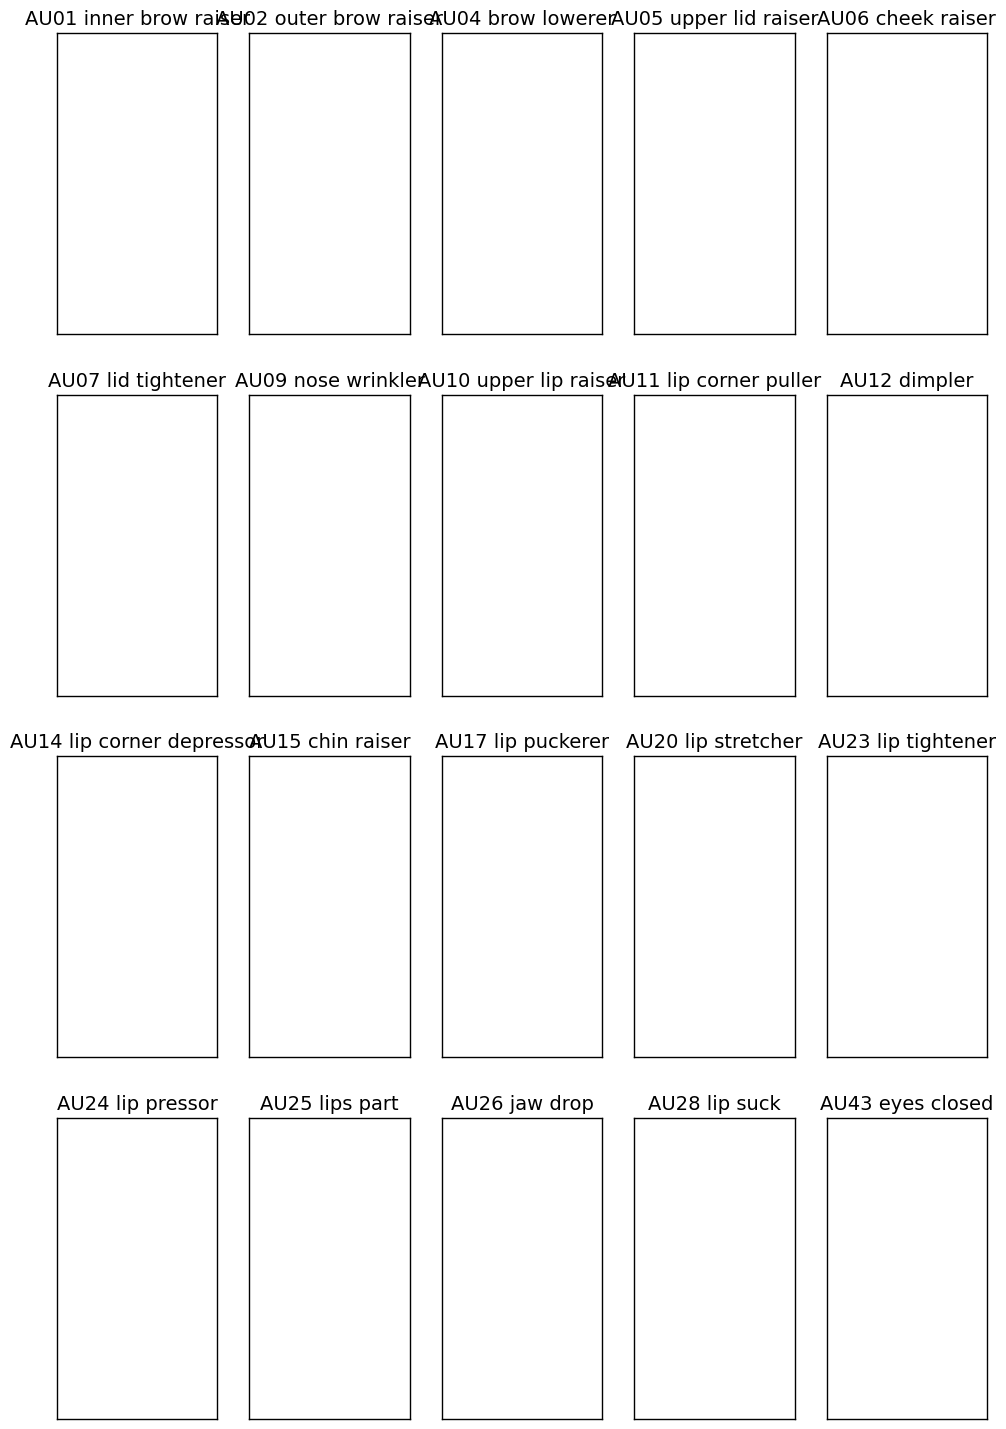

In [15]:
# Loop over each frame of the animation, plot a 4 x 5 grid of faces
fig, axs = plt.subplots(4, 5, figsize=(12, 18))
camera = Camera(fig)

for frame_num in range(total_frames):
    for i, ax in enumerate(axs.flat):
        au_interpolations = interpolate_aus(
            start=starting_intensities[i, :],
            end=ending_intensities[i, :],
            num_frames=num_frames,
            num_padding_frames=num_padding_frames,
        )

        ax = plot_face(
            model=None,
            ax=ax,
            au=au_interpolations[frame_num],
            title=f"{au_name_map[i][0]}\n{au_name_map[i][1]}",
        )
    _ = camera.snap()

# Create the animation
animation = camera.animate()
animation.save("all.gif", fps=fps)

![](../images/all.gif)

### Interactive 2D animation with Plotly

The GIF-based animations above are great for embedding in static docs.
For live notebook exploration there's also `animate_face_plotly()`, which
returns an interactive Plotly Figure with play/pause buttons and a
per-frame slider — you can scrub through the animation by hand, zoom
into a region, and the figure stays interactive throughout. Same
`interpolate_aus` cubic easing as `animate_face` under the hood.

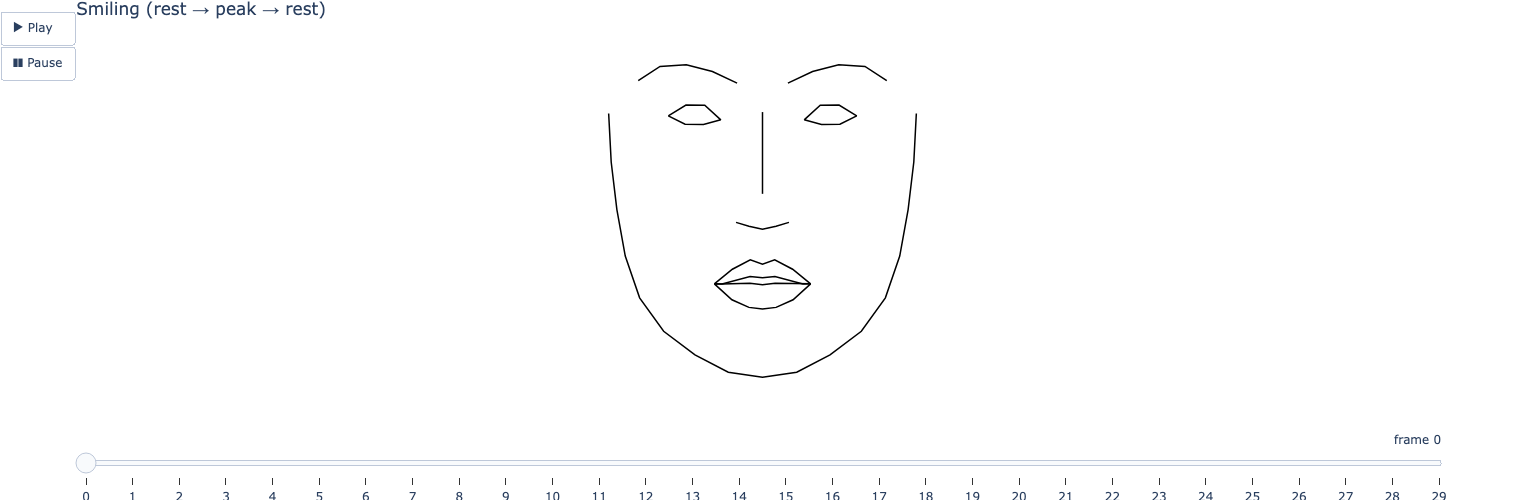

In [16]:
from feat.plotting import animate_face_plotly

# Same smile activation as cell 7 — but as an interactive Plotly animation
# you can pan/zoom and scrub frame-by-frame via the slider, no GIF on disk.
fig_2d_anim = animate_face_plotly(
    start=neutral,
    end=smiling,
    num_frames=15,
    fps=15,
)
fig_2d_anim.update_layout(width=400, height=500, title_text="Smiling (rest → peak → rest)")
fig_2d_anim.show()

## 3.4 Visualizing the full 3D MediaPipe FaceMesh from AU intensities

Beyond the 2D 68-pt landmark plot from `plot_face`, py-feat ships an opt-in 3D
visualization of the full 478-vertex MediaPipe FaceMesh. Pass AU intensities
to `plot_face_mesh()` and the model predicts a face-shaped mesh in a pose-canonical frame, then renders it as a 3D wireframe in matplotlib's 3D backend.

By default `plot_face_mesh()` draws the lighter canonical contours (lips, eyes,
eyebrows, face oval — ~124 edges). Pass `mode='tesselation'` to draw the full
MediaPipe tessellation (~2,556 edges), which reveals the nose, cheek, and
internal-face structure and makes subtle AU activations easier to see. It
matches the default in the interactive Plotly backend used in §3.6.

This relies on the `au_to_mesh` PLS model on HuggingFace
([`py-feat/au_to_mesh`](https://huggingface.co/py-feat/au_to_mesh)) — downloaded
on first use, then cached.


AU columns the model expects: ['AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26', 'AU28', 'AU43']


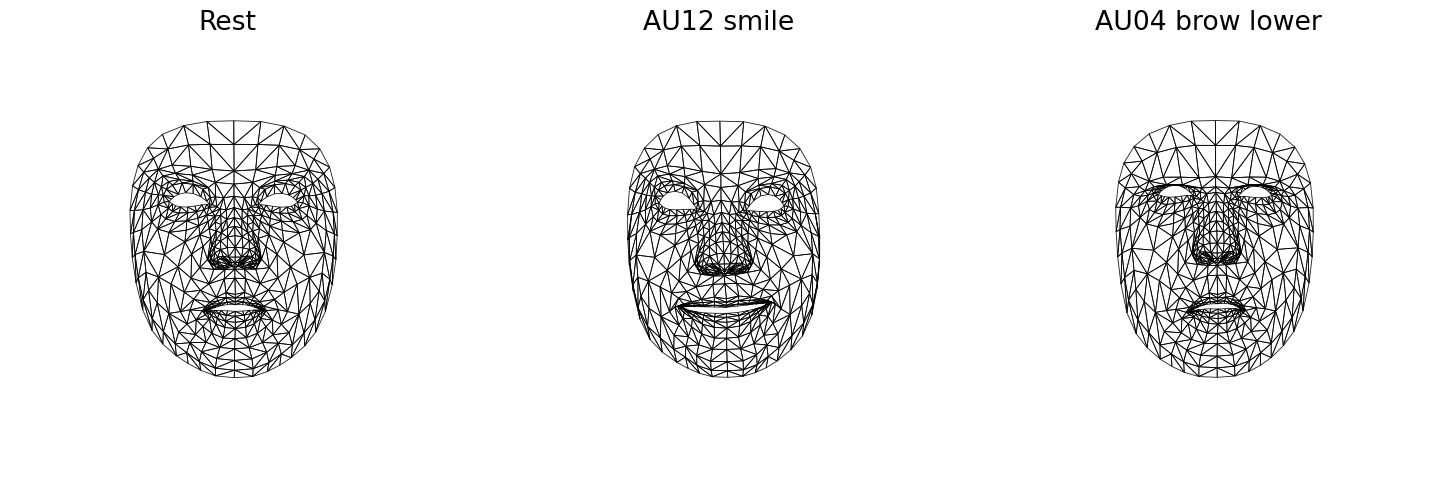

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from feat.plotting import plot_face_mesh, load_face_mesh_viz_model

# Load the model once so we can index AU columns by name
mesh_model = load_face_mesh_viz_model()
au_columns = mesh_model.au_columns
print("AU columns the model expects:", au_columns)

# Build three AU vectors: rest, smile (AU12=3), brow lower (AU04=3)
rest = np.zeros(20, dtype=np.float32)
smile = np.zeros(20, dtype=np.float32); smile[au_columns.index("AU12")] = 3.0
brow  = np.zeros(20, dtype=np.float32); brow[au_columns.index("AU04")]  = 3.0

# Three 3D panels side by side. mode='tesselation' draws the full ~2,556-edge
# MP tessellation (matches plot_face_mesh_plotly's default). Use the lighter
# mode='contours' (~124 edges) if you want a sparser line drawing.
fig = plt.figure(figsize=(15, 5))
for i, (label, au) in enumerate([("Rest", rest),
                                  ("AU12 smile", smile),
                                  ("AU04 brow lower", brow)]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    plot_face_mesh(au=au, ax=ax, model=mesh_model, mode="tesselation")
    ax.set_title(label)
plt.tight_layout()


## 3.5 Bridging 68-pt landmarks to the 3D mesh

If you already ran the standard `Detector` (img2pose + mobilefacenet 68-pt) on
an image, you can convert those 2D landmarks into a 478-vertex 3D mesh using
the `predict_mesh_from_dlib68` bridge. Internally, the function aligns your raw
landmarks to a saved reference frame (Procrustes), applies a PCA-bottleneck
linear regression, and reshapes the output into a `(478, 3)` mesh in the same
canonical-frame coordinates as the AU→mesh model.

The bridge model lives at [`py-feat/landmarks68_to_mesh478`](https://huggingface.co/py-feat/landmarks68_to_mesh478)
and achieves OOS R² ≈ 0.48 on held-out videos — substantially better than
AU → mesh (R² ≈ 0.24) because dlib landmarks share spatial information with
the MP mesh that 20 AU intensities cannot encode.


/var/folders/t6/l70_tp4s3xx96772lc2504640000gn/T/ipykernel_34988/2733464272.py:5: UserWarning: face_model='retinaface' does not regress 6DoF head pose. Pose columns are populated via the landmarks-to-pose MLP (distilled from img2pose on CelebV-HQ, ~5° avg MAE vs img2pose). PnP-DLT is used as a fallback when the MLP weights aren't available. Use face_model='img2pose' for the slowest, highest-accuracy path. See feat.utils.face_pose_mlp for details.
  detector = Detector(au_model="xgb", emotion_model=None, identity_model=None)
100%|██████████| 1/1 [00:00<00:00,  5.23it/s]


predicted mesh shape: (478, 3)


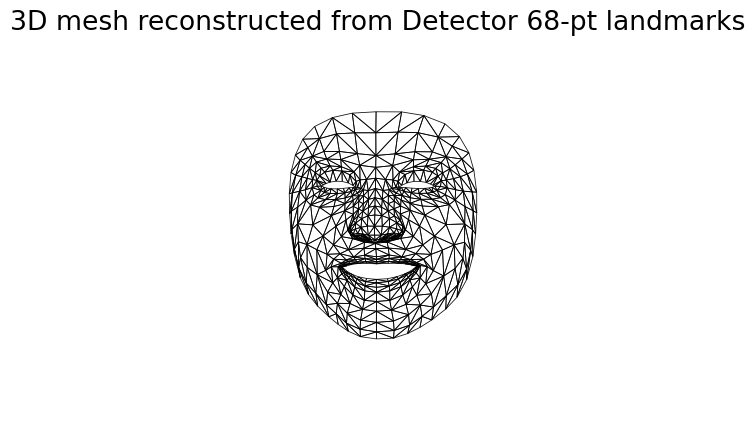

In [18]:
from feat.detector import Detector
from feat.plotting import predict_mesh_from_dlib68

# Run the standard Detector on a test image
detector = Detector(au_model="xgb", emotion_model=None, identity_model=None)
fex = detector.detect(["../../feat/tests/data/single_face.jpg"])

# Use the unified accessor to get dlib-68 landmarks (works on both Detector
# and MPDetector Fex objects — see Fex.landmarks_dlib68_xy)
x, y = fex.landmarks_dlib68_xy()
landmarks_68 = np.column_stack([x[0], y[0]])  # shape (68, 2)

# Bridge to the 3D mesh, then render via plot_face_mesh's mesh= path
mesh = predict_mesh_from_dlib68(landmarks_68)
print("predicted mesh shape:", mesh.shape)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
plot_face_mesh(mesh=mesh, ax=ax, mode="tesselation")
_ = ax.set_title("3D mesh reconstructed from Detector 68-pt landmarks")


## 3.6 Interactive 3D visualization with Plotly

For an interactive 3D viewport you can rotate, pan, and zoom (especially
useful in Jupyter notebooks), `plot_face_mesh_plotly()` returns a
`plotly.graph_objects.Figure` instead of a matplotlib axis. The `mode='tesselation'`
default draws the full 2,556-edge MP tessellation for a dense 3D look; pass
`mode='contours'` for the same canonical-features wireframe as the matplotlib
version.

The function takes the same `au=` / `mesh=` source dispatch as `plot_face_mesh`,
so you can use it with either AU intensities or a precomputed mesh from the
bridge.


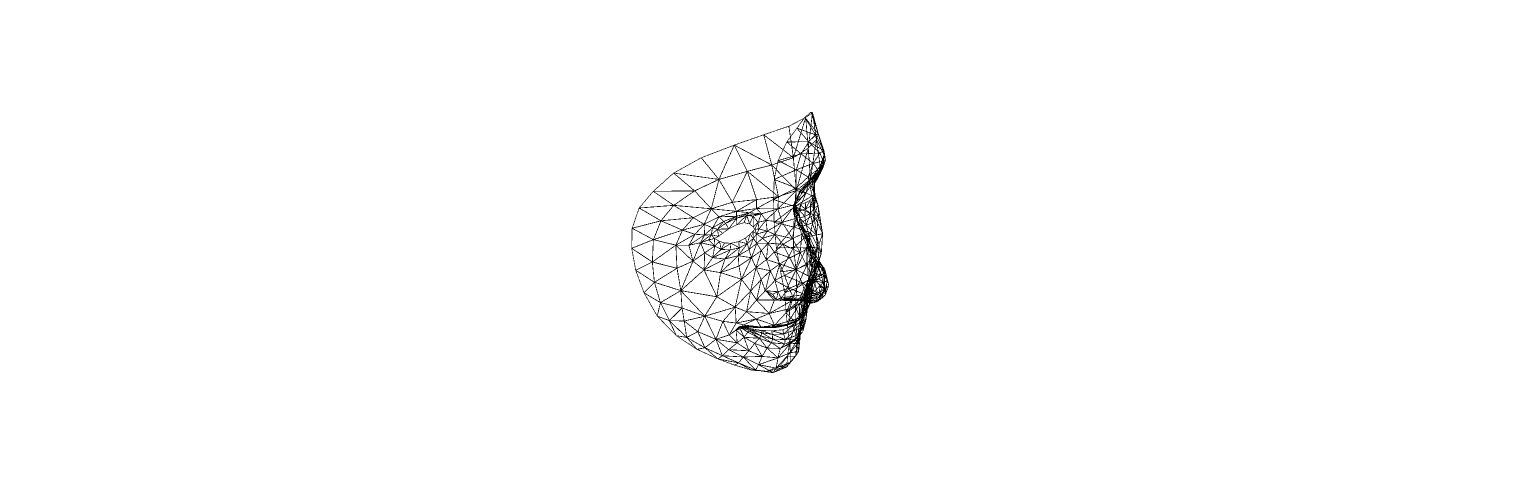

In [19]:
from feat.plotting import plot_face_mesh_plotly

# Same smile activation as 3.4
fig_plotly = plot_face_mesh_plotly(au=smile, mode="tesselation")
fig_plotly.update_layout(width=500, height=500)
fig_plotly.show()


You can also persist the figure to standalone HTML for sharing or to
PNG via Plotly's `write_image()` method (which uses kaleido under the hood):

```python
fig_plotly.write_html("/tmp/face_mesh.html")
fig_plotly.write_image("/tmp/face_mesh.png")
```

For the lighter, contours-only view that matches `plot_face_mesh`:

```python
plot_face_mesh_plotly(au=smile, mode="contours")
```


### Adding a 3D gaze arrow

Both `plot_face_mesh` and `plot_face_mesh_plotly` accept a `gaze=(pitch, yaw)`
tuple of head-centric angles (radians), matching the format L2CS outputs in
`fex.gaze_pitch` / `fex.gaze_yaw`. A yellow arrow is drawn from the
outer-canthi midpoint in the mesh's pose-canonical frame, scaled to
`gaze_length_frac` (default 30%) of face height.

Forward gaze (pitch=0, yaw=0) points along +Z (out of the face), so in
the default front-on plotly camera it appears as a small point — drag to
rotate the camera if you want to see it as an arrow.

In [ ]:
import numpy as np
from feat.plotting import plot_face_mesh_plotly

# Pitch ~+15° (looking up), yaw ~+20° (eyes drift toward viewer's right).
# Pass radians; L2CS detector output is already in radians so you can
# plug fex.gaze_pitch / fex.gaze_yaw straight in. Tesselation mode shows
# enough of the face (nose, cheeks, eyes) for the gaze arrow to read
# anatomically — contours leaves too few landmarks for the eye to be
# obvious.
fig_gaze = plot_face_mesh_plotly(
    au=None,
    mode="tesselation",
    gaze=(np.deg2rad(15), np.deg2rad(20)),
)
fig_gaze.update_layout(width=500, height=500, title_text="Mesh + 3D gaze arrow")
fig_gaze.show()

## 3.7 Animating the 3D MediaPipe FaceMesh

The 2D `animate_face` from §3.3 saves a GIF; the 3D mesh equivalent is
interactive — `animate_face_mesh_plotly()` returns a Plotly Figure with
play/pause/loop buttons and a per-frame slider, and the camera stays
rotatable *while* the animation is playing. So you can rotate to a
profile view, hit play, and watch the expression morph from that vantage.

It uses the same `interpolate_aus` cubic-easing helper as `animate_face`,
and the same `mode='tesselation'` / `'contours'` knob as
`plot_face_mesh_plotly`. By default it appends a reverse pass so the
animation returns to the starting expression on each cycle.

Below we animate a smile starting from rest in tesselation mode — the
dense edge set shows the nose, cheek, and inner-face structure that
makes the face recognizable. Pass `mode='contours'` if you need a
smaller embedded HTML (~500 KB vs several MB for tesselation).

In [ ]:
from feat.plotting import animate_face_mesh_plotly

# Animate from rest → smile → rest. Tesselation mode (default) is much
# more recognizable than contours — contours shows only lips/eyelids/
# brows/face oval, missing nose, cheeks, iris, etc. Tradeoff is HTML
# output size (~5-10 MB for 24 frames vs ~500 KB for contours).
fig_anim = animate_face_mesh_plotly(
    start=rest,
    end=smile,
    num_frames=12,
    fps=15,
    mode="tesselation",
)
fig_anim.update_layout(width=500, height=600, title_text="AU12 smile (rest → peak → rest)")
fig_anim.show()